# CNN Calving Event Classification — Perito Moreno Glacier


**Description:**  
This notebook trains and evaluates a lightweight 2D Convolutional Neural Network (CNN)
for binary classification of calving events at Perito Moreno Glacier (Patagonia, Argentina)
from time-lapse imagery. The model operates on 256×256 RGB image frames and outputs a
calving / no-calving prediction.

**Dataset:**  
Pre-split `.npy` arrays (train / validation / test) must be placed in `DATA_DIR`
(configured in the next cell). See `README.md` for the expected directory structure.

**Requirements:** `tensorflow ≥ 2.10`, `scikit-learn`, `matplotlib`, `seaborn`, `numpy`

## 0 · Configuration
Set `DATA_DIR` to the folder containing the `.npy` dataset files and `OUTPUT_DIR` for saved artefacts.

In [1]:
import os

# ── Paths (edit these to match your local layout) ────────────────────────────
DATA_DIR   = "../data"          # folder with train/val/test .npy files
OUTPUT_DIR = "../outputs"       # folder for saved model, predictions, history

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1 · Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

print("TensorFlow version:", tf.__version__)

I0000 00:00:1779207213.675505    4307 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0


## 2 · Load Dataset

In [3]:
train_images = np.load(os.path.join(DATA_DIR, "train_images.npy"))
train_labels = np.load(os.path.join(DATA_DIR, "train_labels.npy"))
val_images   = np.load(os.path.join(DATA_DIR, "val_images.npy"))
val_labels   = np.load(os.path.join(DATA_DIR, "val_labels.npy"))
test_images  = np.load(os.path.join(DATA_DIR, "test_images.npy"))
test_labels  = np.load(os.path.join(DATA_DIR, "test_labels.npy"))

print("train_images:", train_images.shape, "| train_labels:", train_labels.shape)
print("val_images  :", val_images.shape,   "| val_labels  :", val_labels.shape)
print("test_images :", test_images.shape,  "| test_labels :", test_labels.shape)

train_images: (2320, 256, 256, 3) | train_labels: (2320,)
val_images  : (290, 256, 256, 3) | val_labels  : (290,)
test_images : (290, 256, 256, 3) | test_labels : (290,)


## 3 · Model Architecture

Lightweight 2D CNN with three convolutional blocks followed by three fully-connected layers
and a sigmoid output for binary classification.  
Input shape: `(256, 256, 3)`.  L2 regularisation (λ = 5×10⁻³) and Dropout are applied after
each convolutional block to limit over-fitting.

In [4]:
model = keras.Sequential([
    # Block 1
    layers.Conv2D(32, (5, 5), activation="relu",
                  input_shape=(256, 256, 3),
                  padding="valid",
                  kernel_regularizer=regularizers.l2(5e-3)),
    layers.Dropout(0.10),
    layers.MaxPooling2D(pool_size=(5, 5)),

    # Block 2
    layers.Conv2D(32, (5, 5), activation="relu",
                  padding="valid",
                  kernel_regularizer=regularizers.l2(5e-3)),
    layers.Dropout(0.12),
    layers.MaxPooling2D(pool_size=(5, 5)),

    # Block 3
    layers.Conv2D(16, (3, 3), activation="relu",
                  padding="valid",
                  kernel_regularizer=regularizers.l2(5e-3)),
    layers.Dropout(0.15),
    layers.MaxPooling2D(pool_size=(3, 3)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8,  activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])

model.summary()

/home/catalina/anaconda3/envs/pygmt/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779207222.536503    4307 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 252, 252, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 252, 252, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,441 (138.44 KB)

 Trainable params: 35,441 (138.44 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## 4 · Training

In [6]:
history = model.fit(
    train_images, train_labels,
    epochs=200,
    batch_size=40,
    validation_data=(val_images, val_labels),
    verbose=2,
)

Epoch 1/200


W0000 00:00:1779207224.683170    4307 cpu_allocator_impl.cc:82] Allocation of 1824522240 exceeds 10% of free system memory.
W0000 00:00:1779207226.884764    4415 cpu_allocator_impl.cc:82] Allocation of 325140480 exceeds 10% of free system memory.
W0000 00:00:1779207226.888594    4424 cpu_allocator_impl.cc:82] Allocation of 31457280 exceeds 10% of free system memory.
W0000 00:00:1779207226.888745    4425 cpu_allocator_impl.cc:82] Allocation of 31457280 exceeds 10% of free system memory.
W0000 00:00:1779207226.890854    4421 cpu_allocator_impl.cc:82] Allocation of 31457280 exceeds 10% of free system memory.


58/58 - 56s - 969ms/step - accuracy: 0.4970 - loss: 0.9628 - val_accuracy: 0.5103 - val_loss: 0.9413
Epoch 2/200
58/58 - 80s - 1s/step - accuracy: 0.5073 - loss: 0.9194 - val_accuracy: 0.5172 - val_loss: 0.9036
Epoch 3/200
58/58 - 54s - 923ms/step - accuracy: 0.5112 - loss: 0.8851 - val_accuracy: 0.5552 - val_loss: 0.8725
Epoch 4/200
58/58 - 53s - 919ms/step - accuracy: 0.5448 - loss: 0.8545 - val_accuracy: 0.5966 - val_loss: 0.8460
Epoch 5/200
58/58 - 54s - 924ms/step - accuracy: 0.6060 - loss: 0.8298 - val_accuracy: 0.6759 - val_loss: 0.8249
Epoch 6/200
58/58 - 54s - 933ms/step - accuracy: 0.6565 - loss: 0.8089 - val_accuracy: 0.6345 - val_loss: 0.8028
Epoch 7/200
58/58 - 54s - 927ms/step - accuracy: 0.6793 - loss: 0.7894 - val_accuracy: 0.6862 - val_loss: 0.7850
Epoch 8/200
58/58 - 54s - 934ms/step - accuracy: 0.6897 - loss: 0.7696 - val_accuracy: 0.6724 - val_loss: 0.7649
Epoch 9/200
58/58 - 81s - 1s/step - accuracy: 0.7086 - loss: 0.7436 - val_accuracy: 0.6862 - val_loss: 0.7636
E

In [7]:
# Persist training curves for downstream analysis / figure reproduction
loss_train = history.history["loss"]
loss_val   = history.history["val_loss"]
acc_train  = history.history["accuracy"]
acc_val    = history.history["val_accuracy"]

np.save(os.path.join(OUTPUT_DIR, "history_loss.npy"),         history.history["loss"])
np.save(os.path.join(OUTPUT_DIR, "history_val_loss.npy"),     history.history["val_loss"])
np.save(os.path.join(OUTPUT_DIR, "history_accuracy.npy"),     history.history["accuracy"])
np.save(os.path.join(OUTPUT_DIR, "history_val_accuracy.npy"), history.history["val_accuracy"])

## 5 · Training Curves

In [9]:
# To load curves for plotting or analysis

#loss_train = np.load(os.path.join(OUTPUT_DIR, "history_loss.npy"))
#loss_val   = np.load(os.path.join(OUTPUT_DIR, "history_val_loss.npy"))
#acc_train  = np.load(os.path.join(OUTPUT_DIR, "history_accuracy.npy"))
#acc_val    = np.load(os.path.join(OUTPUT_DIR, "history_val_accuracy.npy"))

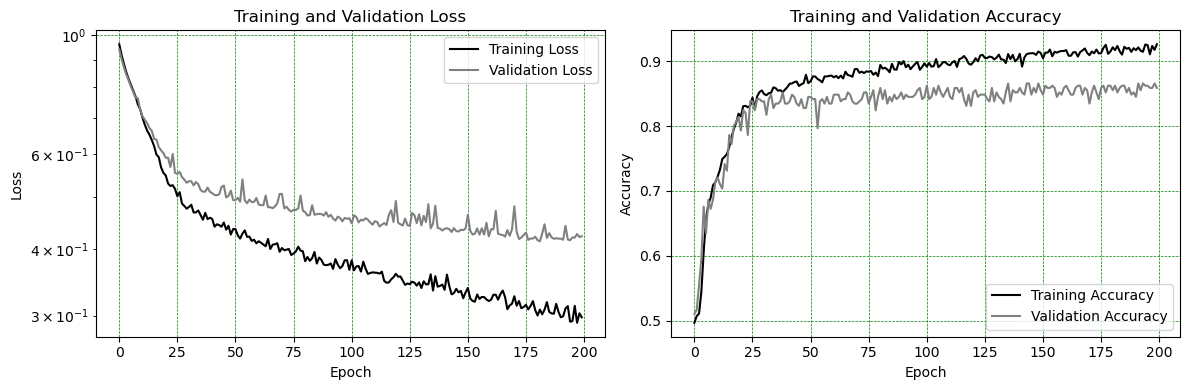

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Training Loss",     color="k")
axes[0].plot(history.history["val_loss"], label="Validation Loss",   color="gray")
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(color="g", linestyle="--", linewidth=0.5)

axes[1].plot(history.history["accuracy"],     label="Training Accuracy",   color="k")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color="gray")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(color="g", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6 · Model Evaluation

In [10]:
train_loss, train_acc = model.evaluate(train_images, train_labels, verbose=0)
val_loss,   val_acc   = model.evaluate(val_images,   val_labels,   verbose=0)
test_loss,  test_acc  = model.evaluate(test_images,  test_labels,  verbose=0)

print(f"Train      — loss: {train_loss:.4f} | accuracy: {train_acc:.4f}")
print(f"Validation — loss: {val_loss:.4f}   | accuracy: {val_acc:.4f}")
print(f"Test       — loss: {test_loss:.4f}  | accuracy: {test_acc:.4f}")

Train      — loss: 0.2943 | accuracy: 0.9409
Validation — loss: 0.4222   | accuracy: 0.8586
Test       — loss: 0.4708  | accuracy: 0.8310


### 6.1 Confusion Matrices

In [12]:
# Predict probabilities for all splits
y_pred_val   = model.predict(val_images)
y_pred_test  = model.predict(test_images)
y_pred_train = model.predict(train_images)

np.save(os.path.join(OUTPUT_DIR, "y_pred_val.npy"),   y_pred_val)
np.save(os.path.join(OUTPUT_DIR, "y_pred_test.npy"),  y_pred_test)
np.save(os.path.join(OUTPUT_DIR, "y_pred_train.npy"), y_pred_train)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step


ValueError: Classification metrics can't handle a mix of binary and continuous targets

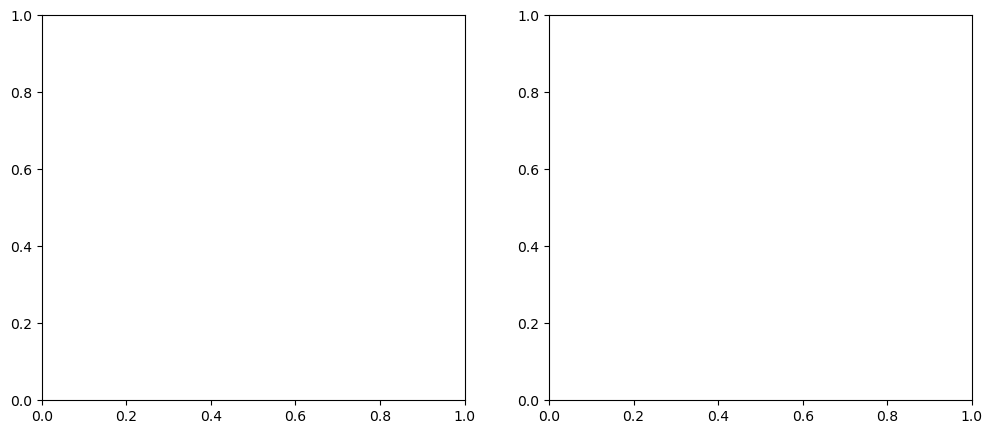

In [ ]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Calving", "Calving"],
                yticklabels=["No Calving", "Calving"], ax=ax)
    ax.set_title(title)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Binarise predictions (threshold = 0.5) and flatten to 1D int arrays
y_pred_val  = (y_pred_val.ravel()  >= 0.5).astype(int)
y_pred_test = (y_pred_test.ravel() >= 0.5).astype(int)

plot_confusion(val_labels.astype(int), y_pred_val, "Confusion Matrix — Validation", axes[0])
plot_confusion(test_labels, y_pred_test, "Confusion Matrix — Test",       axes[1])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.3 · Sample Predictions (Validation Set)

In [ ]:
num_images = 10
fig, axes = plt.subplots(2, num_images, figsize=(20, 4))

for i in range(num_images):
    img_channel = val_images[i].reshape(256, 256, 3)[:, :, 0]
    axes[0, i].imshow(img_channel, cmap="gray")
    axes[0, i].set_title(f"True: {int(val_labels[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_channel, cmap="gray")
    axes[1, i].set_title(f"Pred: {y_pred_val[i]}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Ground Truth", fontsize=10)
axes[1, 0].set_ylabel("Prediction",   fontsize=10)
plt.suptitle("Sample Validation Predictions (0 = No Calving, 1 = Calving)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7 · Save Model

In [ ]:
model_path = os.path.join(OUTPUT_DIR, "model_calving.keras")
model.save(model_path)
print(f"Model saved to: {model_path}")

# Verify the saved model loads correctly
model_calving = load_model(model_path)
print("Model loaded successfully. Input shape:", model_calving.input_shape)